# Assignment 4: Regularization 

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?
2. How does regularization provide a way of exploring the bias-variance trade-off?
3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?
4. How do we typically scale variables for use in regularized regression? Why?
5. How is the penalty $\alpha$ typically selected?
6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

1. Adding a penalty to mean squared error discourages large model parameters that forces the model to balance fitting the data with relative smaller coefficient, which leads to simpler and more stable model.
2. More complex model (more features) have lower bias, but higher variance. Regularization provides a way to reduce model variance and control the complexity of the model, which allows us to find the optimal balance that minimizes generalization error.
3. LASSO penalizes absolute value, which means that it could shrinks coefficients towards zero, removing the feature from the model. Ridge penalizes squared magnitude that shrinks coefficients continuously toward zero but does not eliminate them, which creates a model that keeps all features.
4. Regularization penalizes coefficient size not on the raw variables. Large-scale features will have smaller coefficient and less penalty and small-scale features will have large coefficient and more penalty. Therefore, standardization is important for the regularization to penalize the right coefficient.
5. The penalty parameter is selected using k-fold cross-validation. We pick the coefficients to minimize MSE(b) on the training folds. The alpha that produces the lowest average validation error is selected.
6. The penalty term is not included when evaluating cross-validated MSE because cross-validation is used to estimate prediction error on unseen data.

In [513]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Lasso, LassoCV, LinearRegression


**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them. 
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

In [514]:
cars = pd.read_csv("data/cars_hw.csv")
cars.info()
cars.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 976 entries, 0 to 975
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Unnamed: 0         976 non-null    int64 
 1   Make               976 non-null    object
 2   Make_Year          976 non-null    int64 
 3   Color              976 non-null    object
 4   Body_Type          976 non-null    object
 5   Mileage_Run        976 non-null    int64 
 6   No_of_Owners       976 non-null    object
 7   Seating_Capacity   976 non-null    int64 
 8   Fuel_Type          976 non-null    object
 9   Transmission       976 non-null    object
 10  Transmission_Type  976 non-null    object
 11  Price              976 non-null    int64 
dtypes: int64(5), object(7)
memory usage: 91.6+ KB


,Unnamed: 0,Make_Year,Mileage_Run,Seating_Capacity,Price
count,976.000000,976.000000,976.000000,976.000000,9.760000e+02
mean,488.500000,2016.963115,41571.195697,5.095287,7.410195e+05
std,281.891232,2.818742,24390.995134,0.446224,3.673234e+05
min,1.000000,2011.000000,1117.000000,4.000000,1.880000e+05
25%,244.750000,2015.000000,22676.750000,5.000000,4.757500e+05
50%,488.500000,2017.000000,37570.500000,5.000000,6.665000e+05
75%,732.250000,2019.000000,57421.250000,5.000000,8.830000e+05
max,976.000000,2022.000000,99495.000000,8.000000,2.941000e+06


In [515]:
# 2.1

# add Age column
cars["Age"] = cars["Make_Year"].max() - cars["Make_Year"]
features = cars[["Mileage_Run", "Age"]]

# 3 degree expansion
poly = PolynomialFeatures(degree=3, include_bias=False)
features = poly.fit_transform(features)

# standardize
scaler = StandardScaler()
features = scaler.fit_transform(features)
features

array([[ 0.12469203, -0.01309242, -0.13767332, ..., -0.27188059,
        -0.30655152, -0.38157854],
       [-0.87233418,  0.34185769, -0.79131562, ..., -0.66290736,
        -0.48072553, -0.11762322],
       [-0.49351672, -0.72299265, -0.60062321, ..., -0.6553725 ,
        -0.69153185, -0.66583811],
       ...,
       [ 0.46248973,  1.05175792,  0.19479598, ...,  0.37613381,
         0.72086143,  0.74095672],
       [-0.54294553, -1.07794277, -0.62951357, ..., -0.70830243,
        -0.76065848, -0.72094966],
       [-0.01621083, -0.36804254, -0.25974731, ..., -0.43760422,
        -0.51343241, -0.55851562]], shape=(976, 9))

In [516]:
# 2.2

# set X and y
X = features
y = cars["Price"]

model = LinearRegression()
model.fit(X,y)

feature_names = poly.get_feature_names_out(["Mileage_Run", "Age"])
for name, coef in zip(feature_names, model.coef_):
    if name == "Mileage_Run Age":
        print(name, coef)

Mileage_Run Age -898405.7513563768


In [517]:
for name, coef in zip(feature_names, model.coef_):  
    print(name, coef)

Mileage_Run 458071.11962682597
Age -136698.07209968244
Mileage_Run^2 -91643.12002368404
Mileage_Run Age -898405.7513563768
Age^2 113603.8223477252
Mileage_Run^3 -65144.89659917471
Mileage_Run^2 Age 229021.67655600805
Mileage_Run Age^2 368955.7133591455
Age^3 -84038.06614621934


The sign is negative.

In [518]:
# 2.3

# alpha grid
alphas = np.logspace(1, 3, 20)

# fit LassoCV 
lasso_cv = LassoCV(alphas=alphas, cv=20, max_iter=10000, random_state=100)
lasso_cv.fit(X, y)

# best alpha
print("Best alpha:", lasso_cv.alpha_)

# coefficients
feature_names = poly.get_feature_names_out(["Mileage_Run", "Age"])
for name, coef in zip(feature_names, lasso_cv.coef_):
    print(name, coef)

Best alpha: 784.7599703514607
Mileage_Run 279901.14447524666
Age -178627.64941808867
Mileage_Run^2 -0.0
Mileage_Run Age -430522.3711668114
Age^2 -0.0
Mileage_Run^3 -30772.352392202065
Mileage_Run^2 Age 0.0
Mileage_Run Age^2 224381.0273389626
Age^3 5666.626834897177


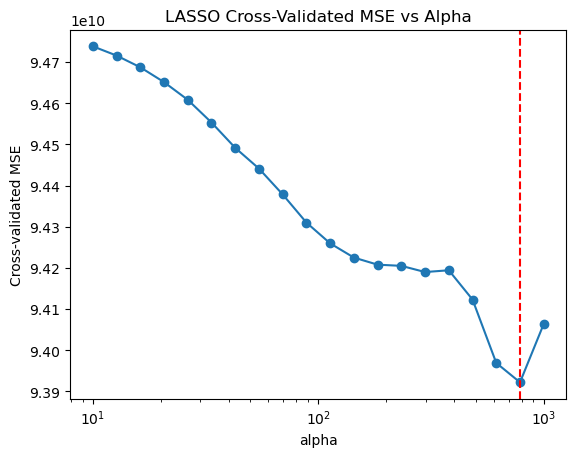

In [519]:
# 2.4
mean_mse = np.mean(lasso_cv.mse_path_, axis=1)

plt.figure()
plt.plot(lasso_cv.alphas_, mean_mse, marker='o')
plt.xscale("log")
plt.axvline(lasso_cv.alpha_, color='red', linestyle='--')
plt.xlabel("alpha")
plt.ylabel("Cross-validated MSE")
plt.title("LASSO Cross-Validated MSE vs Alpha")

plt.show()

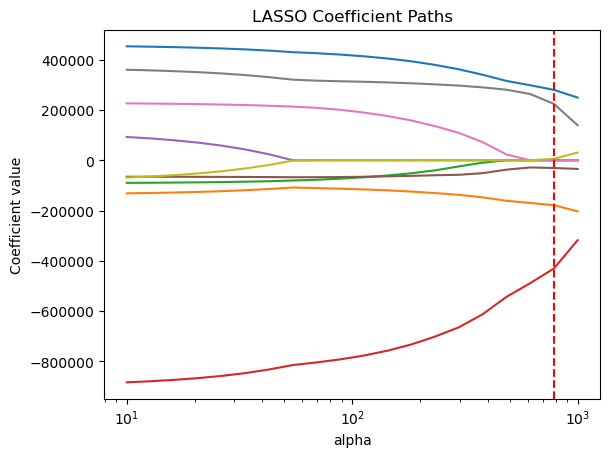

In [520]:
# 2.5
alphas = np.logspace(1, 3, 20)
coefs = []

# compute coefficients
for alpha in alphas:
    model = Lasso(alpha=alpha, max_iter=10000)
    model.fit(X, y)
    coefs.append(model.coef_)

coefs = np.array(coefs)

# plot
plt.figure()
for i in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:, i])
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Coefficient value")
plt.title("LASSO Coefficient Paths")

# mark best alpha
plt.axvline(lasso_cv.alpha_, color='red', linestyle='--')
plt.show()

In [521]:
# 2.6
select = []
zero = []

for name, coef in zip(feature_names, lasso_cv.coef_):
    if coef != 0:
        select.append(name)
    else:
        zero.append(name)

print("Selected features:", select)
print("Zeroed features:", zero)

Selected features: ['Mileage_Run', 'Age', 'Mileage_Run Age', 'Mileage_Run^3', 'Mileage_Run Age^2', 'Age^3']
Zeroed features: ['Mileage_Run^2', 'Age^2', 'Mileage_Run^2 Age']


### 2.7
The linear regression model produces very large and unstable coefficients, such as the interaction term between mileage and age (−898,405), as well as serval higher-order interaction terms with opposing signs. This indicates multi-collinearity and overfitting, as the model uses many correlated features and assigns large coefficients that cancel each other. In contrast, the LASSO model shrinks coefficient magnitudes and eliminates several features, which reduces the interaction term to approximately −430,522 and setting predictors to zero. In general, the coefficients do not increase from OLS to LASSO instead they are reduced. The most sign of coefficients remain consistent (except age^3).

**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

In [522]:
hearts = pd.read_csv("data/heart_failure_clinical_records_dataset.csv")
hearts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [523]:
# 3.1

# a)
features = hearts[["age", "ejection_fraction", "serum_creatinine"]]

poly = PolynomialFeatures(degree=3, include_bias=False)
features = poly.fit_transform(features)
features = scaler.fit_transform(features)

# b)
cat = hearts[["anaemia", "diabetes", "high_blood_pressure", "smoking"]]

poly_interaction = PolynomialFeatures(degree=4, include_bias = False, interaction_only=True)
cat = poly_interaction.fit_transform(cat)

# c)
X = np.hstack([features, cat])
features_names = poly.get_feature_names_out(["age", "ejection_fraction", "serum_creatinine"])

cat_names = poly_interaction.get_feature_names_out(["anaemia", "diabetes", "high_blood_pressure", "smoking"])

feature_names = list(features_names) + list(cat_names)
X

array([[ 1.19294523, -1.53055953,  0.49005699, ...,  0.        ,
         0.        ,  0.        ],
       [-0.49127928, -0.00707675, -0.28455235, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.35083298, -1.53055953, -0.09090002, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-1.33339153,  1.85495776, -0.57503085, ...,  0.        ,
         0.        ,  0.        ],
       [-1.33339153, -0.00707675,  0.00592615, ...,  0.        ,
         0.        ,  0.        ],
       [-0.9123354 ,  0.58538877,  0.19957848, ...,  0.        ,
         0.        ,  0.        ]], shape=(299, 34))

In [524]:
# 3.2
y = hearts["DEATH_EVENT"]
model = LinearRegression()
model.fit(X, y)

for name, coef in zip(feature_names, model.coef_):
    print(name, coef)

age 1.6194322676575046
ejection_fraction -2.062276998301064
serum_creatinine -0.7570916028758281
age^2 -3.7177583123320175
age ejection_fraction -0.8007261185943206
age serum_creatinine 1.7070563789142392
ejection_fraction^2 3.352955761851507
ejection_fraction serum_creatinine 2.569763966996399
serum_creatinine^2 -2.640240359095034
age^3 1.9631244241572985
age^2 ejection_fraction 1.0544082536442196
age^2 serum_creatinine -0.6790419239566228
age ejection_fraction^2 -0.06643268506854945
age ejection_fraction serum_creatinine -1.626996060083342
age serum_creatinine^2 1.4440747914551575
ejection_fraction^3 -1.2453368697783764
ejection_fraction^2 serum_creatinine -1.1513782782787703
ejection_fraction serum_creatinine^2 1.1895162115833446
serum_creatinine^3 -0.0491805089279474
anaemia -0.015590281463908503
diabetes -0.12437379463187843
high_blood_pressure -0.041251380017595714
smoking -0.14258327271577848
anaemia diabetes 0.08270367129360845
anaemia high_blood_pressure -0.030591605766491007


Several coefficients seem counterintuitive such as negative coefficient for serum_creatinine, smoking, and diabetes, which contradicts to the Common Sense that those factor attributes to death. This occurs because multi-collinearity among polynomial and interaction features, which makes each coefficient hard to interpret. 

In [525]:
# 3.3
alphas = np.logspace(-5, 5, 30)

lasso_cv = LassoCV(alphas=alphas, cv=20, max_iter=10000, random_state=100)
lasso_cv.fit(X, y)

print("Best alpha:", lasso_cv.alpha_)

for name, coef in zip(feature_names, lasso_cv.coef_):
    print(name, coef)

/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.276e+00, tolerance: 5.832e-03
  model = cd_fast.enet_coordinate_descent_gram(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.051e+00, tolerance: 5.832e-03
  model = cd_fast.enet_coordinate_descent_gram(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.4

Best alpha: 0.005736152510448681
age -0.0
ejection_fraction -0.32965588260124196
serum_creatinine 0.11687513008140925
age^2 0.0
age ejection_fraction -0.0
age serum_creatinine 0.0
ejection_fraction^2 0.0
ejection_fraction serum_creatinine 0.0
serum_creatinine^2 -0.0
age^3 0.11799179769122638
age^2 ejection_fraction 0.0
age^2 serum_creatinine 0.0
age ejection_fraction^2 0.0
age ejection_fraction serum_creatinine 0.0
age serum_creatinine^2 -0.0
ejection_fraction^3 0.20482163816168658
ejection_fraction^2 serum_creatinine 0.032801101897877626
ejection_fraction serum_creatinine^2 -0.0
serum_creatinine^3 -0.043266082830255945
anaemia 0.014178336344470393
diabetes 0.000606503635601683
high_blood_pressure 0.013608157191952427
smoking -0.0
anaemia diabetes 0.0
anaemia high_blood_pressure 0.0
anaemia smoking 0.0
diabetes high_blood_pressure 0.053968467022895365
diabetes smoking 0.0034664278424865907
high_blood_pressure smoking 0.017805277845004318
anaemia diabetes high_blood_pressure 0.0
anaemia

/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.151e-01, tolerance: 6.322e-03
  model = cd_fast.enet_coordinate_descent_gram(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.947e-01, tolerance: 6.322e-03
  model = cd_fast.enet_coordinate_descent_gram(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.7

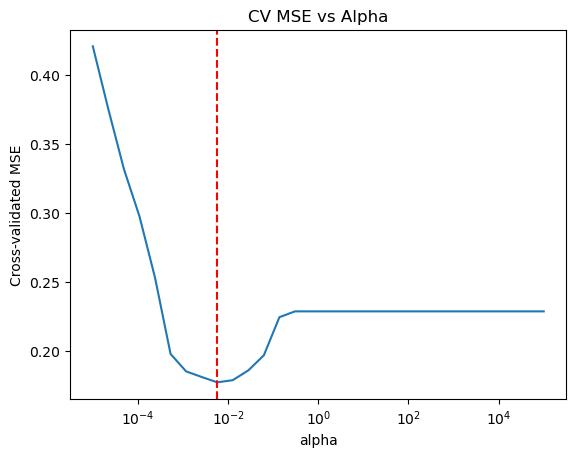

In [526]:
# 3.4
mse_mean = np.mean(lasso_cv.mse_path_, axis=1)

plt.figure()
plt.plot(lasso_cv.alphas_, mse_mean)
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Cross-validated MSE")
plt.title("CV MSE vs Alpha")
plt.axvline(lasso_cv.alpha_, color='red', linestyle="--")
plt.show()

/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.872e+01, tolerance: 6.518e-03
  model = cd_fast.enet_coordinate_descent(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.631e+01, tolerance: 6.518e-03
  model = cd_fast.enet_coordinate_descent(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.059e+01, to

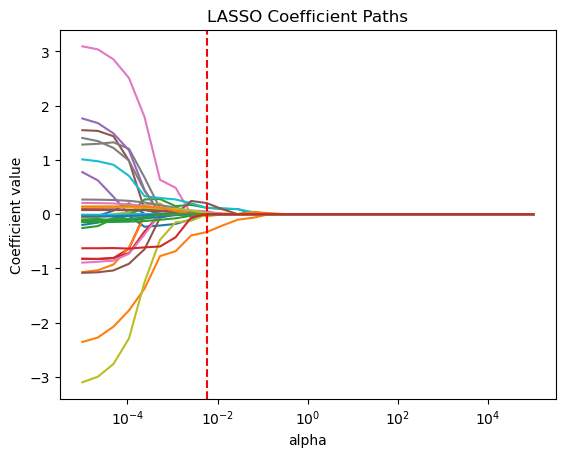

In [527]:
# 4.5
alphas = np.logspace(-5, 5, 30)

coefs = []
for a in alphas:
    lasso = Lasso(alpha=a, max_iter=10000)
    lasso.fit(X, y)
    coefs.append(lasso.coef_)

coefs = np.array(coefs)

plt.figure()
for i in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:, i])   

plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Coefficient value")
plt.title("LASSO Coefficient Paths")

plt.axvline(lasso_cv.alpha_, color='red', linestyle="--")
plt.show()

In [528]:
selected = lasso_cv.coef_ != 0
num_selected = np.sum(selected)
num_zero = np.sum(lasso_cv.coef_ == 0)
prop_zero = num_zero / len(lasso_cv.coef_)

print("Selected features:", num_selected)
print("Zero coefficients:", num_zero)
print("Proportion zero:", prop_zero)

for name, coef in zip(feature_names, lasso_cv.coef_):
    if coef != 0:
        print(name, coef)

Selected features: 12
Zero coefficients: 22
Proportion zero: 0.6470588235294118
ejection_fraction -0.32965588260124196
serum_creatinine 0.11687513008140925
age^3 0.11799179769122638
ejection_fraction^3 0.20482163816168658
ejection_fraction^2 serum_creatinine 0.032801101897877626
serum_creatinine^3 -0.043266082830255945
anaemia 0.014178336344470393
diabetes 0.000606503635601683
high_blood_pressure 0.013608157191952427
diabetes high_blood_pressure 0.053968467022895365
diabetes smoking 0.0034664278424865907
high_blood_pressure smoking 0.017805277845004318


The LASSO model selects 12 out of 34 features and sets 22 coefficients to zero, which is approximately 64.7% of the predictors. In contrast, regression model uses every features as coefficients, including the higher-order and interaction terms. The OLS coefficients are often large and exhibit unstable or counterintuitive signs, such as the negative coefficient for smoking and diabetes. After regularization, LASSO shrinks most coefficients and removes redundant variables, which results a smaller magnitudes and a sparser model. Meanwhile, some coefficients changes sign, for example serum_creatinine, smoking, diabetes. The LASSO model’s sign patterns are more interpretable because regularization reduces multi-collinearity and aligns with common sense . From a bias–variance perspective, OLS has low bias but high variance, while LASSO introduces bias to significantly reduce variance, which creates a more reliable and interpretable model.

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

![description](IMG_9284.jpeg)

![description](IMG_9285.jpeg)